# **Check GPU Availability**


In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Dependancies** **Installation**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

**Folder** **Creation**

In [3]:
import os

os.makedirs("data/raw", exist_ok=True)

print("Folder created successfully!")

Folder created successfully!


In [4]:
!wget -O data/raw/human_activity.zip "https://archive.ics.uci.edu/static/public/341/smartphone+based+recognition+of+human+activities+and+postural+transitions.zip"


--2026-09-19 09:42:21--  https://archive.ics.uci.edu/static/public/341/smartphone+based+recognition+of+human+activities+and+postural+transitions.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘data/raw/human_activity.zip’

data/raw/human_acti     [            <=>     ]  75.91M  18.2MB/s    in 5.3s    

2026-09-19 09:42:28 (14.3 MB/s) - ‘data/raw/human_activity.zip’ saved [79596192]



In [5]:
!unzip -q data/raw/human_activity.zip -d data/raw/

In [6]:
!ls -R data/raw/


data/raw/:
activity_labels.txt  features.txt	 RawData     Test
features_info.txt    human_activity.zip  README.txt  Train

data/raw/RawData:
acc_exp01_user01.txt  acc_exp42_user21.txt   gyro_exp22_user11.txt
acc_exp02_user01.txt  acc_exp43_user21.txt   gyro_exp23_user11.txt
acc_exp03_user02.txt  acc_exp44_user22.txt   gyro_exp24_user12.txt
acc_exp04_user02.txt  acc_exp45_user22.txt   gyro_exp25_user12.txt
acc_exp05_user03.txt  acc_exp46_user23.txt   gyro_exp26_user13.txt
acc_exp06_user03.txt  acc_exp47_user23.txt   gyro_exp27_user13.txt
acc_exp07_user04.txt  acc_exp48_user24.txt   gyro_exp28_user14.txt
acc_exp08_user04.txt  acc_exp49_user24.txt   gyro_exp29_user14.txt
acc_exp09_user05.txt  acc_exp50_user25.txt   gyro_exp30_user15.txt
acc_exp10_user05.txt  acc_exp51_user25.txt   gyro_exp31_user15.txt
acc_exp11_user06.txt  acc_exp52_user26.txt   gyro_exp32_user16.txt
acc_exp12_user06.txt  acc_exp53_user26.txt   gyro_exp33_user16.txt
acc_exp13_user07.txt  acc_exp54_user27.txt   gyro_exp34

In [7]:
import pandas as pd

activity_labels = pd.read_csv(
    "data/raw/activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["label", "activity"]
)

print(activity_labels)

    label            activity
0       1             WALKING
1       2    WALKING_UPSTAIRS
2       3  WALKING_DOWNSTAIRS
3       4             SITTING
4       5            STANDING
5       6              LAYING
6       7        STAND_TO_SIT
7       8        SIT_TO_STAND
8       9          SIT_TO_LIE
9      10          LIE_TO_SIT
10     11        STAND_TO_LIE
11     12        LIE_TO_STAND


**Load the Training** **Data**

In [8]:
X_train = pd.read_csv(
    "data/raw/Train/X_train.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    "data/raw/Train/y_train.txt",
    sep=r"\s+",
    header=None,
    names=["label"]
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (7767, 561)
y_train shape: (7767, 1)


561-dimensional feature vector.

In [9]:
print("\nFirst 5 rows of X_train:")
display(X_train.head(10))

print("\nFirst 10 labels:")
display(y_train.head(50))


First 5 rows of X_train:


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.043580,-0.005970,-0.035054,-0.995381,-0.988366,-0.937382,-0.995007,-0.988816,-0.953325,-0.794796,...,-0.012236,-0.314848,-0.713308,-0.112754,0.030400,-0.464761,-0.018446,-0.841559,0.179913,-0.051718
1,0.039480,-0.002131,-0.029067,-0.998348,-0.982945,-0.971273,-0.998702,-0.983315,-0.974000,-0.802537,...,0.202804,-0.603199,-0.860677,0.053477,-0.007435,-0.732626,0.703511,-0.845092,0.180261,-0.047436
2,0.039978,-0.005153,-0.022651,-0.995482,-0.977314,-0.984760,-0.996415,-0.975835,-0.985973,-0.798477,...,0.440079,-0.404427,-0.761847,-0.118559,0.177899,0.100699,0.808529,-0.849230,0.180610,-0.042271
3,0.039785,-0.011809,-0.028916,-0.996194,-0.988569,-0.993256,-0.996994,-0.988526,-0.993135,-0.798477,...,0.430891,-0.138373,-0.491604,-0.036788,-0.012892,0.640011,-0.485366,-0.848947,0.181907,-0.040826
4,0.038758,-0.002289,-0.023863,-0.998241,-0.986774,-0.993115,-0.998216,-0.986479,-0.993825,-0.801982,...,0.137735,-0.366214,-0.702490,0.123320,0.122542,0.693578,-0.615971,-0.848164,0.185124,-0.037080
5,0.038988,0.004109,-0.017340,-0.997438,-0.993485,-0.996692,-0.997522,-0.993494,-0.996916,-0.801982,...,0.074999,-0.554902,-0.844224,0.082632,-0.143439,0.275041,-0.368224,-0.849927,0.184795,-0.035326
6,0.039897,-0.005324,-0.020457,-0.997024,-0.977313,-0.987782,-0.996898,-0.977450,-0.989391,-0.800606,...,0.191486,-0.235576,-0.571126,-0.212754,-0.230622,0.014637,-0.189512,-0.852441,0.182142,-0.036203
7,0.039082,-0.016047,-0.030241,-0.996662,-0.976996,-0.986672,-0.996380,-0.977594,-0.989310,-0.800606,...,0.182731,-0.104337,-0.432022,-0.020888,0.593996,-0.561871,0.467383,-0.851309,0.183751,-0.035176
8,0.039026,-0.007410,-0.027301,-0.997431,-0.973190,-0.988183,-0.997491,-0.971557,-0.990156,-0.800245,...,0.347118,-0.286366,-0.579474,0.012954,0.080936,-0.234313,0.117797,-0.848270,0.188955,-0.030594
9,0.040354,0.004245,-0.017932,-0.994906,-0.981181,-0.990046,-0.995300,-0.982483,-0.990920,-0.799717,...,0.303948,0.306076,0.115919,-0.020590,-0.127730,-0.482871,-0.070670,-0.848592,0.190283,-0.027667



First 10 labels:


,label
0,5
1,5
2,5
3,5
4,5
5,5
6,5
7,5
8,5
9,5


In [10]:
features = pd.read_csv(
    "data/raw/features.txt",
    sep=r"\s+",
    header=None,
    names=["index", "feature"]
)

print("Number of features:", len(features))
display(features.head(20))

Number of features: 561


,index,feature
0,tBodyAcc-Mean-1,NaN
1,tBodyAcc-Mean-2,NaN
2,tBodyAcc-Mean-3,NaN
3,tBodyAcc-STD-1,NaN
4,tBodyAcc-STD-2,NaN
5,tBodyAcc-STD-3,NaN
6,tBodyAcc-Mad-1,NaN
7,tBodyAcc-Mad-2,NaN
8,tBodyAcc-Mad-3,NaN
9,tBodyAcc-Max-1,NaN


In [13]:
display(features.tail(20))

,index,feature
541,fBodyGyroJerkMag-Mean-1,NaN
542,fBodyGyroJerkMag-STD-1,NaN
543,fBodyGyroJerkMag-Mad-1,NaN
544,fBodyGyroJerkMag-Max-1,NaN
545,fBodyGyroJerkMag-Min-1,NaN
546,fBodyGyroJerkMag-SMA-1,NaN
547,fBodyGyroJerkMag-Energy-1,NaN
548,fBodyGyroJerkMag-IQR-1,NaN
549,fBodyGyroJerkMag-ropy-1,NaN
550,fBodyGyroJerkMag-MaxInds-1,NaN


In [14]:
print(features["feature"].to_string(index=False))

NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN
NaN


In [15]:
class_counts = y_train["label"].value_counts().sort_index()

print(class_counts)

label
1     1226
2     1073
3      987
4     1293
5     1423
6     1413
7       47
8       23
9       75
10      60
11      90
12      57
Name: count, dtype: int64


In [16]:
features = pd.read_csv(
    "data/raw/features.txt",
    header=None,
    names=["feature"]
)

print("Number of features:", len(features))
display(features.head(20))

Number of features: 561


,feature
0,tBodyAcc-Mean-1
1,tBodyAcc-Mean-2
2,tBodyAcc-Mean-3
3,tBodyAcc-STD-1
4,tBodyAcc-STD-2
5,tBodyAcc-STD-3
6,tBodyAcc-Mad-1
7,tBodyAcc-Mad-2
8,tBodyAcc-Mad-3
9,tBodyAcc-Max-1


In [17]:
print(features.tail(20))

                             feature
541  fBodyGyroJerkMag-Mean-1        
542  fBodyGyroJerkMag-STD-1         
543  fBodyGyroJerkMag-Mad-1         
544  fBodyGyroJerkMag-Max-1         
545  fBodyGyroJerkMag-Min-1         
546  fBodyGyroJerkMag-SMA-1         
547  fBodyGyroJerkMag-Energy-1      
548  fBodyGyroJerkMag-IQR-1         
549  fBodyGyroJerkMag-ropy-1        
550  fBodyGyroJerkMag-MaxInds-1     
551  fBodyGyroJerkMag-MeanFreq-1    
552  fBodyGyroJerkMag-Skewness-1    
553  fBodyGyroJerkMag-Kurtosis-1    
554  tBodyAcc-AngleWRTGravity-1     
555  tBodyAccJerk-AngleWRTGravity-1 
556  tBodyGyro-AngleWRTGravity-1    
557  tBodyGyroJerk-AngleWRTGravity-1
558  tXAxisAcc-AngleWRTGravity-1    
559  tYAxisAcc-AngleWRTGravity-1    
560  tZAxisAcc-AngleWRTGravity-1    


In [18]:
raw_acc = pd.read_csv(
    "data/raw/RawData/acc_exp01_user01.txt",
    sep=r"\s+",
    header=None
)

print("Shape:", raw_acc.shape)

display(raw_acc.head(10))

Shape: (20598, 3)


,0,1,2
0,0.918056,-0.112500,0.509722
1,0.911111,-0.093056,0.537500
2,0.881944,-0.086111,0.513889
3,0.881944,-0.086111,0.513889
4,0.879167,-0.100000,0.505556
5,0.888889,-0.105556,0.512500
6,0.862500,-0.101389,0.509722
7,0.861111,-0.104167,0.501389
8,0.854167,-0.108333,0.527778
9,0.851389,-0.101389,0.552778


In [19]:
print(raw_acc.describe())

                  0             1             2
count  20598.000000  20598.000000  20598.000000
mean       0.880673     -0.101714      0.097088
std        0.346449      0.340091      0.285555
min       -0.647222     -1.209722     -0.676389
25%        0.805556     -0.285764     -0.081944
50%        0.981945     -0.202778     -0.004167
75%        1.019445     -0.031944      0.204167
max        1.950000      1.036111      1.269444


In [20]:
raw_labels = pd.read_csv(
    "data/raw/RawData/labels.txt",
    sep=r"\s+",
    header=None
)

print("Shape:", raw_labels.shape)

display(raw_labels.head(20))

Shape: (1214, 5)


,0,1,2,3,4
0,1,1,5,250,1232
1,1,1,7,1233,1392
2,1,1,4,1393,2194
3,1,1,8,2195,2359
4,1,1,5,2360,3374
5,1,1,11,3375,3662
6,1,1,6,3663,4538
7,1,1,10,4539,4735
8,1,1,4,4736,5667
9,1,1,9,5668,5859


In [21]:
display(raw_labels.tail(20))

,0,1,2,3,4
1194,61,30,5,574,1622
1195,61,30,7,1623,1838
1196,61,30,4,1839,2772
1197,61,30,8,2773,2900
1198,61,30,5,2901,4197
1199,61,30,11,4198,4446
1200,61,30,6,4447,5657
1201,61,30,10,5658,5896
1202,61,30,4,5897,7165
1203,61,30,9,7166,7457


In [22]:
print(activity_labels)

    label            activity
0       1             WALKING
1       2    WALKING_UPSTAIRS
2       3  WALKING_DOWNSTAIRS
3       4             SITTING
4       5            STANDING
5       6              LAYING
6       7        STAND_TO_SIT
7       8        SIT_TO_STAND
8       9          SIT_TO_LIE
9      10          LIE_TO_SIT
10     11        STAND_TO_LIE
11     12        LIE_TO_STAND


In [23]:
raw_gyro = pd.read_csv(
    "data/raw/RawData/gyro_exp01_user01.txt",
    sep=r"\s+",
    header=None
)

print("Gyroscope shape:", raw_gyro.shape)
display(raw_gyro.head())

Gyroscope shape: (20598, 3)


,0,1,2
0,-0.054978,-0.069639,-0.030849
1,-0.012523,0.019242,-0.038485
2,-0.023518,0.276417,0.006414
3,-0.093462,0.367741,0.001222
4,-0.124311,0.476780,-0.022907


# **Experiment: 1**
User: 1
Sensor: Accelerometer
Axis: X
Total samples: 20,598
Sampling rate: 50 Hz

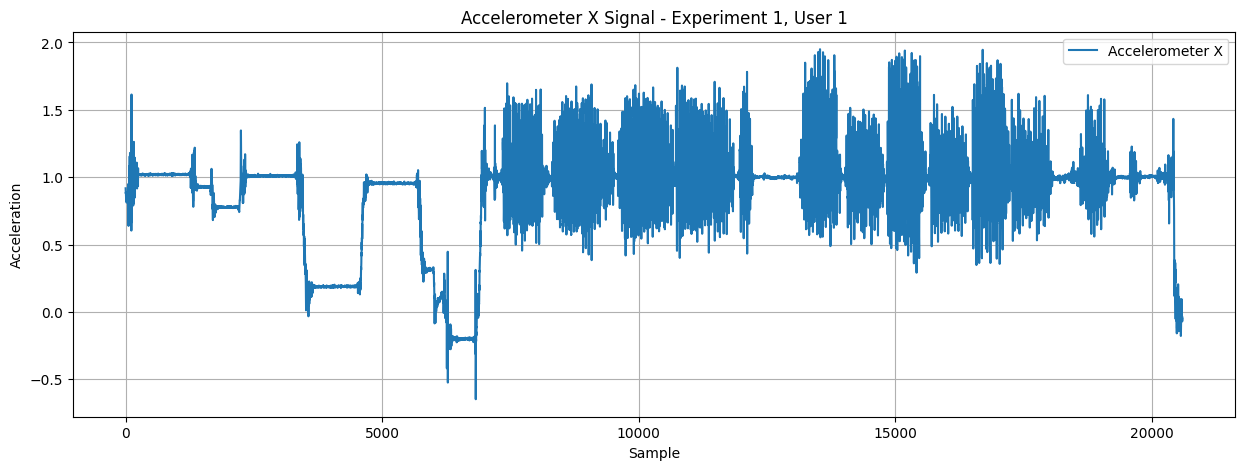

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(raw_acc[0], label="Accelerometer X")

plt.xlabel("Sample")
plt.ylabel("Acceleration")
plt.title("Accelerometer X Signal - Experiment 1, User 1")
plt.legend()
plt.grid(True)

plt.show()

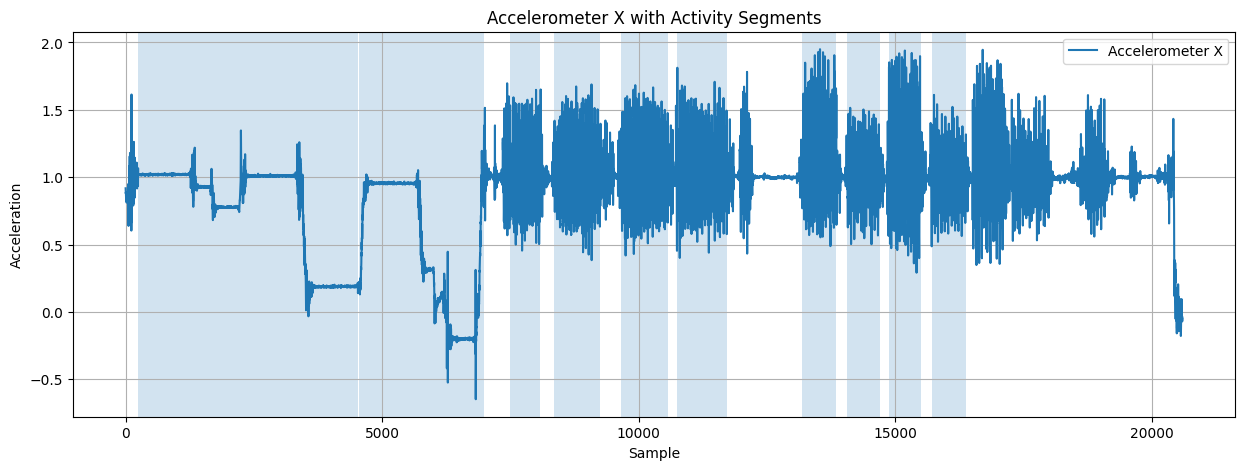

In [25]:
plt.figure(figsize=(15, 5))

plt.plot(raw_acc[0], label="Accelerometer X")

# Show the first 20 labeled activity segments
for _, row in raw_labels.head(20).iterrows():
    experiment = int(row[0])
    user = int(row[1])
    activity_id = int(row[2])
    start = int(row[3])
    end = int(row[4])

    # Only show labels belonging to Experiment 1, User 1
    if experiment == 1 and user == 1:
        plt.axvspan(
            start,
            end,
            alpha=0.2
        )

plt.xlabel("Sample")
plt.ylabel("Acceleration")
plt.title("Accelerometer X with Activity Segments")
plt.legend()
plt.grid(True)

plt.show()


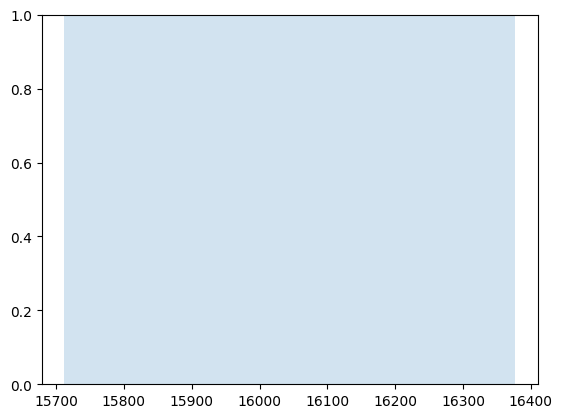

In [26]:
plt.axvspan(start, end, alpha=0.2)

In [27]:
# Select labels for Experiment 1, User 1
exp1_user1_labels = raw_labels[
    (raw_labels[0] == 1) &
    (raw_labels[1] == 1)
].copy()

# Rename columns
exp1_user1_labels.columns = [
    "experiment",
    "user",
    "activity_id",
    "start",
    "end"
]

# Map activity ID to activity name
activity_map = dict(
    zip(activity_labels["label"], activity_labels["activity"])
)

exp1_user1_labels["activity"] = (
    exp1_user1_labels["activity_id"].map(activity_map)
)

# Calculate number of samples in each labelled segment
exp1_user1_labels["num_samples"] = (
    exp1_user1_labels["end"] -
    exp1_user1_labels["start"] + 1
)

display(exp1_user1_labels)

,experiment,user,activity_id,start,end,activity,num_samples
0,1,1,5,250,1232,STANDING,983
1,1,1,7,1233,1392,STAND_TO_SIT,160
2,1,1,4,1393,2194,SITTING,802
3,1,1,8,2195,2359,SIT_TO_STAND,165
4,1,1,5,2360,3374,STANDING,1015
5,1,1,11,3375,3662,STAND_TO_LIE,288
6,1,1,6,3663,4538,LAYING,876
7,1,1,10,4539,4735,LIE_TO_SIT,197
8,1,1,4,4736,5667,SITTING,932
9,1,1,9,5668,5859,SIT_TO_LIE,192


In [28]:
WINDOW_SIZE = 128
STEP = 64

exp1_user1_labels["num_windows"] = (
    (exp1_user1_labels["num_samples"] - WINDOW_SIZE) // STEP + 1
)

display(
    exp1_user1_labels[
        ["activity", "num_samples", "num_windows"]
    ]
)

,activity,num_samples,num_windows
0,STANDING,983,14
1,STAND_TO_SIT,160,1
2,SITTING,802,11
3,SIT_TO_STAND,165,1
4,STANDING,1015,14
5,STAND_TO_LIE,288,3
6,LAYING,876,12
7,LIE_TO_SIT,197,2
8,SITTING,932,13
9,SIT_TO_LIE,192,2


In [29]:
train_subjects = pd.read_csv(
    "data/raw/Train/subject_id_train.txt",
    header=None
)

test_subjects = pd.read_csv(
    "data/raw/Test/subject_id_test.txt",
    header=None
)

print("Number of training samples:", len(train_subjects))
print("Number of test samples:", len(test_subjects))

print("\nUnique training subjects:")
print(sorted(train_subjects[0].unique()))

print("\nUnique test subjects:")
print(sorted(test_subjects[0].unique()))

Number of training samples: 7767
Number of test samples: 3162

Unique training subjects:
[np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]

Unique test subjects:
[np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]


In [30]:
# Check which users/subjects are present in the raw labels
raw_users = sorted(raw_labels[1].unique())

print("Number of unique users:", len(raw_users))
print("Users:", raw_users)

Number of unique users: 30
Users: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]


In [31]:
# Number of labelled experiment-user combinations
experiment_users = raw_labels[[0, 1]].drop_duplicates()

print("Number of experiment-user combinations:",
      len(experiment_users))

display(experiment_users.head(20))

Number of experiment-user combinations: 61


,0,1
0,1,1
22,2,1
45,3,2
65,4,2
85,5,3
106,6,3
126,7,4
147,8,4
167,9,5
187,10,5


In [32]:
sensor_data = np.column_stack([
    raw_acc.values,
    raw_gyro.values
])

print("Combined sensor shape:", sensor_data.shape)

display(pd.DataFrame(
    sensor_data,
    columns=[
        "acc_x", "acc_y", "acc_z",
        "gyro_x", "gyro_y", "gyro_z"
    ]
).head())

Combined sensor shape: (20598, 6)


,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
0,0.918056,-0.112500,0.509722,-0.054978,-0.069639,-0.030849
1,0.911111,-0.093056,0.537500,-0.012523,0.019242,-0.038485
2,0.881944,-0.086111,0.513889,-0.023518,0.276417,0.006414
3,0.881944,-0.086111,0.513889,-0.093462,0.367741,0.001222
4,0.879167,-0.100000,0.505556,-0.124311,0.476780,-0.022907


In [33]:
WINDOW_SIZE = 128
STEP = 64

X_windows = []
y_windows = []

# Get labels for Experiment 1, User 1
labels_exp1_user1 = raw_labels[
    (raw_labels[0] == 1) &
    (raw_labels[1] == 1)
]

for _, row in labels_exp1_user1.iterrows():

    activity_id = int(row[2])
    start = int(row[3])
    end = int(row[4])

    # Convert dataset sample numbering to Python indexing
    segment = sensor_data[start - 1:end]

    # Create windows inside this activity segment only
    for i in range(
        0,
        len(segment) - WINDOW_SIZE + 1,
        STEP
    ):
        window = segment[i:i + WINDOW_SIZE]

        X_windows.append(window)
        y_windows.append(activity_id)

# Convert to NumPy arrays
X_windows = np.array(X_windows)
y_windows = np.array(y_windows)

print("X shape:", X_windows.shape)
print("y shape:", y_windows.shape)

X shape: (185, 128, 6)
y shape: (185,)


In [34]:
print("First window shape:", X_windows[0].shape)

print("\nFirst window:")
display(pd.DataFrame(
    X_windows[0],
    columns=[
        "acc_x", "acc_y", "acc_z",
        "gyro_x", "gyro_y", "gyro_z"
    ]
).head(10))

print("\nFirst window label ID:", y_windows[0])
print("First window activity:", activity_map[y_windows[0]])

First window shape: (128, 6)

First window:


,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
0,1.020833,-0.125000,0.104167,-0.000916,0.001833,0.002749
1,1.020833,-0.125000,0.105556,-0.002749,-0.004276,0.002749
2,1.025000,-0.125000,0.101389,-0.000305,-0.002138,0.006109
3,1.020833,-0.125000,0.104167,0.012217,0.000916,-0.007330
4,1.016667,-0.125000,0.108333,0.011301,-0.001833,-0.006414
5,1.018056,-0.127778,0.108333,0.010996,-0.001527,-0.004887
6,1.018056,-0.129167,0.104167,0.009163,-0.003054,0.010079
7,1.019445,-0.125000,0.101389,0.010079,-0.003665,0.000305
8,1.016667,-0.123611,0.097222,0.013744,-0.014966,0.004276
9,1.020833,-0.127778,0.098611,0.009774,-0.006414,0.000305



First window label ID: 5
First window activity: STANDING


In [35]:
window_counts = pd.Series(y_windows).map(activity_map).value_counts()

display(window_counts)

,count
WALKING,47
STANDING,28
WALKING_UPSTAIRS,26
LAYING,25
WALKING_DOWNSTAIRS,25
SITTING,24
STAND_TO_LIE,3
LIE_TO_SIT,2
SIT_TO_LIE,2
STAND_TO_SIT,1


In [37]:
def create_windows_for_experiment(
    experiment,
    user,
    window_size=128,
    step=64
):
    """
    Load accelerometer and gyroscope data for one
    experiment/user combination and create labelled windows.
    """

    # -----------------------------
    # 1. Create file paths
    # -----------------------------
    acc_path = (
        f"data/raw/RawData/"
        f"acc_exp{experiment:02d}_user{user:02d}.txt"
    )

    gyro_path = (
        f"data/raw/RawData/"
        f"gyro_exp{experiment:02d}_user{user:02d}.txt"
    )

    # -----------------------------
    # 2. Load sensor data
    # -----------------------------
    acc = pd.read_csv(
        acc_path,
        sep=r"\s+",
        header=None
    ).values

    gyro = pd.read_csv(
        gyro_path,
        sep=r"\s+",
        header=None
    ).values

    # -----------------------------
    # 3. Combine 6 channels
    # -----------------------------
    sensor_data = np.column_stack([
        acc,
        gyro
    ])

    # -----------------------------
    # 4. Get labels for this
    #    experiment + user
    # -----------------------------
    labels = raw_labels[
        (raw_labels[0] == experiment) &
        (raw_labels[1] == user)
    ]

    X = []
    y = []

    # -----------------------------
    # 5. Process each activity
    # -----------------------------
    for _, row in labels.iterrows():

        activity_id = int(row[2])
        start = int(row[3])
        end = int(row[4])

        # Dataset uses sample numbering starting from 1
        segment = sensor_data[start - 1:end]

        # -------------------------
        # 6. Create windows
        # -------------------------
        for i in range(
            0,
            len(segment) - window_size + 1,
            step
        ):

            window = segment[
                i:i + window_size
            ]

            X.append(window)
            y.append(activity_id)

    return np.array(X), np.array(y)

In [38]:
X_test_one, y_test_one = create_windows_for_experiment(
    experiment=1,
    user=1
)

print("X shape:", X_test_one.shape)
print("y shape:", y_test_one.shape)

X shape: (185, 128, 6)
y shape: (185,)
